#### DATA

In [2]:
try: # running in Google Colab
  from google.colab import drive
  drive.mount('/content/gdrive')
  root="/content/gdrive/MyDrive/Blockhouse_Trial_Task"
except: # running locally
  root='/Users/yalidrahman/Desktop/Fordham_MSQF'
root

Mounted at /content/gdrive


'/content/gdrive/MyDrive/Blockhouse_Trial_Task'

In [4]:
pwd

'/content'

In [7]:
cd ..{root}

/content/gdrive/MyDrive/Blockhouse_Trial_Task


In [8]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from datetime import datetime


# Load the CSV file directly
data = pd.read_csv('first_25000_rows.csv')

# Convert timestamp columns to datetime
data['ts_event'] = pd.to_datetime(data['ts_event'])
data['ts_recv'] = pd.to_datetime(data['ts_recv'])

# Display the shape and first few rows
print(data.shape)
data.head()


(5000, 74)


,ts_recv,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,...,ask_sz_08,bid_ct_08,ask_ct_08,bid_px_09,ask_px_09,bid_sz_09,ask_sz_09,bid_ct_09,ask_ct_09,symbol
0,2024-10-21 11:54:29.221230963+00:00,2024-10-21 11:54:29.221064336+00:00,10,2,38,C,B,1,233.62,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
1,2024-10-21 11:54:29.223936626+00:00,2024-10-21 11:54:29.223769812+00:00,10,2,38,A,B,0,233.67,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
2,2024-10-21 11:54:29.225196809+00:00,2024-10-21 11:54:29.225030400+00:00,10,2,38,A,B,0,233.67,3,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
3,2024-10-21 11:54:29.712600612+00:00,2024-10-21 11:54:29.712434212+00:00,10,2,38,A,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
4,2024-10-21 11:54:29.764839221+00:00,2024-10-21 11:54:29.764673165+00:00,10,2,38,C,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL


In [10]:
def calculate_best_level_ofi(data, time_window='1min'):
    """
    Calculate the best-level Order Flow Imbalance (OFI) as defined in Cont et al. (2014).

    The formula is: OFI = sum(OF_bid - OF_ask) over the time interval
    where OF_bid and OF_ask are order flows calculated from changes in best bid/ask.
    """
    # Sort data by timestamp
    data = data.sort_values('ts_event')

    # Create a copy of the data with only relevant columns
    ofi_data = data[['ts_event', 'symbol', 'bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00']].copy()

    # Group by time intervals and symbol
    grouped = ofi_data.groupby([pd.Grouper(key='ts_event', freq=time_window), 'symbol'])

    best_level_ofi = []

    for (timestamp, symbol), group in grouped:
        if len(group) <= 1:
            continue

        # Calculate order flow for each update in the group
        group = group.sort_values('ts_event')

        # Initialize arrays to store order flows
        of_bid = np.zeros(len(group) - 1)
        of_ask = np.zeros(len(group) - 1)

        for i in range(len(group) - 1):
            current = group.iloc[i]
            next_state = group.iloc[i+1]

            # Calculate bid order flow
            if next_state['bid_px_00'] > current['bid_px_00']:
                of_bid[i] = next_state['bid_sz_00']
            elif next_state['bid_px_00'] == current['bid_px_00']:
                of_bid[i] = next_state['bid_sz_00'] - current['bid_sz_00']
            else:
                of_bid[i] = -current['bid_sz_00']

            # Calculate ask order flow
            if next_state['ask_px_00'] > current['ask_px_00']:
                of_ask[i] = -next_state['ask_sz_00']
            elif next_state['ask_px_00'] == current['ask_px_00']:
                of_ask[i] = next_state['ask_sz_00'] - current['ask_sz_00']
            else:
                of_ask[i] = next_state['ask_sz_00']

        # Calculate OFI as the sum of (OF_bid - OF_ask)
        ofi = np.sum(of_bid - of_ask)

        # Calculate average depth to scale OFI
        avg_depth = np.mean([row['bid_sz_00'] + row['ask_sz_00'] for _, row in group.iterrows()]) / 2
        scaled_ofi = ofi / avg_depth if avg_depth > 0 else 0

        best_level_ofi.append({
            'timestamp': timestamp,
            'symbol': symbol,
            'best_level_ofi': scaled_ofi
        })

    return pd.DataFrame(best_level_ofi)

In [11]:
def calculate_multi_level_ofi(data, time_window='1min', max_level=10):
    """
    Calculate multi-level Order Flow Imbalance (OFI) as defined in the research paper.

    For each level m, OFI^m is calculated, then scaled by the average order book depth.
    """
    # Sort data by timestamp
    data = data.sort_values('ts_event')

    # Create a time interval grouping
    grouped = data.groupby([pd.Grouper(key='ts_event', freq=time_window), 'symbol'])

    multi_level_ofi_list = []

    for (timestamp, symbol), group in grouped:
        if len(group) <= 1:
            continue

        # Calculate OFI for each level
        level_ofis = {}

        group = group.sort_values('ts_event')

        # Calculate total average depth across M levels for scaling
        total_avg_depth = 0
        for m in range(max_level):
            bid_col = f'bid_sz_{m:02d}'
            ask_col = f'ask_sz_{m:02d}'
            if bid_col in group.columns and ask_col in group.columns:
                avg_level_depth = np.mean([row[bid_col] + row[ask_col] for _, row in group.iterrows()]) / 2
                total_avg_depth += avg_level_depth

        total_avg_depth /= max_level

        # Calculate OFI for each level
        for m in range(max_level):
            bid_px_col = f'bid_px_{m:02d}'
            ask_px_col = f'ask_px_{m:02d}'
            bid_sz_col = f'bid_sz_{m:02d}'
            ask_sz_col = f'ask_sz_{m:02d}'

            if all(col in group.columns for col in [bid_px_col, ask_px_col, bid_sz_col, ask_sz_col]):
                of_bid = np.zeros(len(group) - 1)
                of_ask = np.zeros(len(group) - 1)

                for i in range(len(group) - 1):
                    current = group.iloc[i]
                    next_state = group.iloc[i+1]

                    # Calculate bid order flow at level m
                    if next_state[bid_px_col] > current[bid_px_col]:
                        of_bid[i] = next_state[bid_sz_col]
                    elif next_state[bid_px_col] == current[bid_px_col]:
                        of_bid[i] = next_state[bid_sz_col] - current[bid_sz_col]
                    else:
                        of_bid[i] = -current[bid_sz_col]

                    # Calculate ask order flow at level m
                    if next_state[ask_px_col] > current[ask_px_col]:
                        of_ask[i] = -next_state[ask_sz_col]
                    elif next_state[ask_px_col] == current[ask_px_col]:
                        of_ask[i] = next_state[ask_sz_col] - current[ask_sz_col]
                    else:
                        of_ask[i] = next_state[ask_sz_col]

                # Calculate OFI for level m
                ofi_m = np.sum(of_bid - of_ask)

                # Scale by average depth
                scaled_ofi_m = ofi_m / total_avg_depth if total_avg_depth > 0 else 0

                level_ofis[f'ofi_level_{m}'] = scaled_ofi_m

        # Add to results
        result = {
            'timestamp': timestamp,
            'symbol': symbol
        }
        result.update(level_ofis)
        multi_level_ofi_list.append(result)

    return pd.DataFrame(multi_level_ofi_list)

In [12]:
def calculate_integrated_ofi(multi_level_ofi_df, train_period=None):
    """
    Calculate the integrated OFI based on principal component analysis of multi-level OFIs.

    This uses the first principal component of the multi-level OFI data.
    """
    # Get unique symbols
    symbols = multi_level_ofi_df['symbol'].unique()

    integrated_ofi_list = []

    for symbol in symbols:
        symbol_data = multi_level_ofi_df[multi_level_ofi_df['symbol'] == symbol].copy()

        # Extract OFI columns
        ofi_columns = [col for col in symbol_data.columns if 'ofi_level_' in col]

        if not ofi_columns:
            continue

        # Determine training data for PCA
        if train_period:
            train_data = symbol_data[symbol_data['timestamp'] <= train_period][ofi_columns]
        else:
            # Use all data for PCA if no training period is specified
            train_data = symbol_data[ofi_columns]

        # Apply PCA to get the first principal component
        if train_data.shape[0] > 0 and train_data.shape[1] > 0:
            # Handle potential NaN values
            train_data = train_data.fillna(0)

            pca = PCA(n_components=1)
            pca.fit(train_data)

            # Get the weights (first principal component)
            weights = pca.components_[0]

            # Normalize weights to sum to 1
            weights = weights / np.sum(np.abs(weights))

            # Calculate integrated OFI for all data
            ofi_data = symbol_data[ofi_columns].fillna(0)
            integrated_ofi = ofi_data.dot(weights)

            # Add to results
            for i, idx in enumerate(symbol_data.index):
                integrated_ofi_list.append({
                    'timestamp': symbol_data.loc[idx, 'timestamp'],
                    'symbol': symbol,
                    'integrated_ofi': integrated_ofi.iloc[i]
                })

    return pd.DataFrame(integrated_ofi_list)

In [13]:
def calculate_cross_asset_ofi(ofi_df, returns_df, lookback_window=30):
    """
    Calculate cross-asset OFI based on LASSO regression of returns against OFIs.

    This implementation focuses on identifying which other assets' OFIs affect a given asset's returns.
    """
    from sklearn.linear_model import Lasso

    # Get unique symbols and timestamps
    symbols = ofi_df['symbol'].unique()
    timestamps = sorted(ofi_df['timestamp'].unique())

    cross_asset_ofi_list = []

    # Process each symbol
    for target_symbol in symbols:
        # For each time period
        for t_idx in range(lookback_window, len(timestamps)):
            current_time = timestamps[t_idx]

            # Get training data (lookback window)
            train_start = timestamps[t_idx - lookback_window]
            train_times = timestamps[t_idx - lookback_window:t_idx]

            # Prepare X (OFIs from all symbols) and y (returns of target symbol)
            X_train = []
            feature_names = []

            for t in train_times:
                row = []
                # For each symbol, get its OFI at time t
                for source_symbol in symbols:
                    ofi_val = ofi_df[(ofi_df['symbol'] == source_symbol) &
                                    (ofi_df['timestamp'] == t)]['integrated_ofi'].values
                    if len(ofi_val) > 0:
                        row.append(ofi_val[0])
                    else:
                        row.append(0)

                    if t == train_start:  # Only add feature names once
                        feature_names.append(f'ofi_{source_symbol}')

                X_train.append(row)

            X_train = np.array(X_train)

            # Get target returns
            y_train = []
            for t in train_times:
                ret_val = returns_df[(returns_df['symbol'] == target_symbol) &
                                   (returns_df['timestamp'] == t)]['return'].values
                if len(ret_val) > 0:
                    y_train.append(ret_val[0])
                else:
                    y_train.append(0)

            y_train = np.array(y_train)

            # Fit LASSO model
            if len(X_train) > 0 and len(y_train) > 0:
                model = Lasso(alpha=0.01)
                try:
                    model.fit(X_train, y_train)

                    # Get coefficients
                    coeffs = dict(zip(feature_names, model.coef_))

                    # Calculate cross-asset OFI as weighted sum of other assets' OFIs
                    current_ofi_values = {}
                    for source_symbol in symbols:
                        ofi_val = ofi_df[(ofi_df['symbol'] == source_symbol) &
                                        (ofi_df['timestamp'] == current_time)]['integrated_ofi'].values
                        if len(ofi_val) > 0:
                            current_ofi_values[f'ofi_{source_symbol}'] = ofi_val[0]
                        else:
                            current_ofi_values[f'ofi_{source_symbol}'] = 0

                    # Calculate self and cross components
                    self_component = coeffs[f'ofi_{target_symbol}'] * current_ofi_values[f'ofi_{target_symbol}']

                    cross_component = 0
                    for source_symbol in symbols:
                        if source_symbol != target_symbol:
                            cross_component += coeffs[f'ofi_{source_symbol}'] * current_ofi_values[f'ofi_{source_symbol}']

                    cross_asset_ofi_list.append({
                        'timestamp': current_time,
                        'symbol': target_symbol,
                        'self_ofi_component': self_component,
                        'cross_ofi_component': cross_component,
                        'total_cross_asset_ofi': self_component + cross_component
                    })
                except:
                    # Handle potential fitting errors
                    pass

    return pd.DataFrame(cross_asset_ofi_list)

In [25]:
# Calculate returns
def calculate_returns(data, time_window='1min'):
    """Calculate log returns from mid-prices."""
    # Sort data by timestamp
    data = data.sort_values('ts_event')

    # Create a copy with only relevant columns
    price_data = data[['ts_event', 'symbol', 'bid_px_00', 'ask_px_00']].copy()

    # Calculate mid-price
    price_data['mid_price'] = (price_data['bid_px_00'] + price_data['ask_px_00']) / 2

    # Group by time intervals and symbol
    grouped = price_data.groupby([pd.Grouper(key='ts_event', freq=time_window), 'symbol'])

    returns_list = []

    for (timestamp, symbol), group in grouped:
        if len(group) < 2:  # Need at least two prices to calculate a return
            continue

        # Get first and last mid-price in the interval
        first_price = group.iloc[0]['mid_price']
        last_price = group.iloc[-1]['mid_price']

        # Calculate log return
        log_return = np.log(last_price / first_price) if first_price > 0 and last_price > 0 else 0

        returns_list.append({
            'timestamp': timestamp,
            'symbol': symbol,
            'return': log_return
        })

    return pd.DataFrame(returns_list)

# Execute the calculations
time_window = '1min'

# 1. Calculate Best-Level OFI
best_level_ofi_df = calculate_best_level_ofi(data, time_window)
print(f"Best-Level OFI calculation: {len(best_level_ofi_df)} rows")

# 2. Calculate Multi-Level OFI
multi_level_ofi_df = calculate_multi_level_ofi(data, time_window)
print(f"Multi-Level OFI calculation : {len(multi_level_ofi_df)} rows")

# 3. Calculate Integrated OFI
integrated_ofi_df = calculate_integrated_ofi(multi_level_ofi_df)
print(f"Integrated OFI calculation: {len(integrated_ofi_df)} rows")

# 4. Calculate returns for Cross-Asset OFI
returns_df = calculate_returns(data, time_window)
print(f"Returns calculation: {len(returns_df)} rows")

# 5. Calculate Cross-Asset OFI
cross_asset_ofi_df = calculate_cross_asset_ofi(integrated_ofi_df, returns_df)
print(f"Cross-Asset OFI calculation: {len(cross_asset_ofi_df)} rows")

Best-Level OFI calculation: 71 rows
Multi-Level OFI calculation : 71 rows
Integrated OFI calculation: 71 rows
Returns calculation: 71 rows
Cross-Asset OFI calculation: 41 rows


In [15]:
best_level_ofi_df.head()

,timestamp,symbol,best_level_ofi
0,2024-10-21 11:54:00+00:00,AAPL,-2.544976
1,2024-10-21 11:55:00+00:00,AAPL,-5.378008
2,2024-10-21 11:56:00+00:00,AAPL,2.613114
3,2024-10-21 11:57:00+00:00,AAPL,5.808827
4,2024-10-21 11:58:00+00:00,AAPL,3.150116


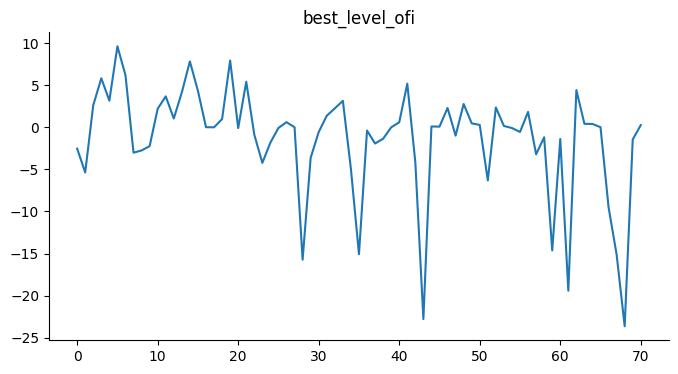

In [17]:
# @title best_level_ofi

from matplotlib import pyplot as plt
best_level_ofi_df['best_level_ofi'].plot(kind='line', figsize=(8, 4), title='best_level_ofi')
plt.gca().spines[['top', 'right']].set_visible(False)

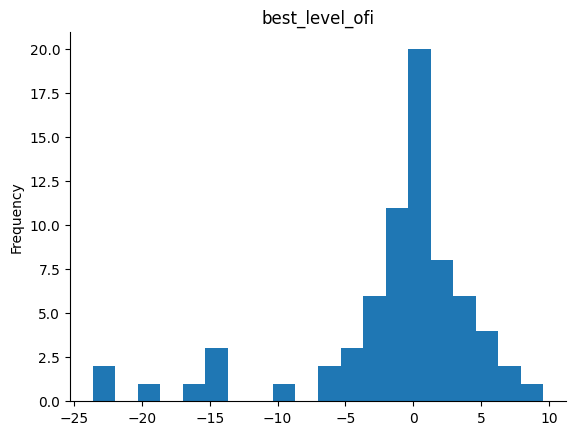

In [16]:
# @title best_level_ofi

from matplotlib import pyplot as plt
best_level_ofi_df['best_level_ofi'].plot(kind='hist', bins=20, title='best_level_ofi')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [18]:
multi_level_ofi_df.head()

,timestamp,symbol,ofi_level_0,ofi_level_1,ofi_level_2,ofi_level_3,ofi_level_4,ofi_level_5,ofi_level_6,ofi_level_7,ofi_level_8,ofi_level_9
0,2024-10-21 11:54:00+00:00,AAPL,-3.651216,5.625097,1.408591,-1.399324,0.194608,5.328551,0.407750,-1.454926,5.764102,4.550119
1,2024-10-21 11:55:00+00:00,AAPL,-7.494269,7.337755,13.543084,-0.478749,-0.920672,5.045282,-1.095600,0.193341,8.810830,-6.509150
2,2024-10-21 11:56:00+00:00,AAPL,2.737712,0.063880,10.421557,-2.737712,3.212249,0.255520,-0.857816,6.506629,-2.792466,3.650283
3,2024-10-21 11:57:00+00:00,AAPL,7.792882,2.562165,4.929286,0.115253,-12.190231,5.461223,3.244818,-4.787436,11.915397,-0.585131
4,2024-10-21 11:58:00+00:00,AAPL,4.147305,7.667286,6.726301,1.001975,0.575046,-11.797165,10.507667,1.280785,7.336199,20.318309


In [21]:
integrated_ofi_df.head()

,timestamp,symbol,integrated_ofi
0,2024-10-21 11:54:00+00:00,AAPL,-3.093998
1,2024-10-21 11:55:00+00:00,AAPL,-1.774571
2,2024-10-21 11:56:00+00:00,AAPL,1.432809
3,2024-10-21 11:57:00+00:00,AAPL,-4.633192
4,2024-10-21 11:58:00+00:00,AAPL,-3.240255


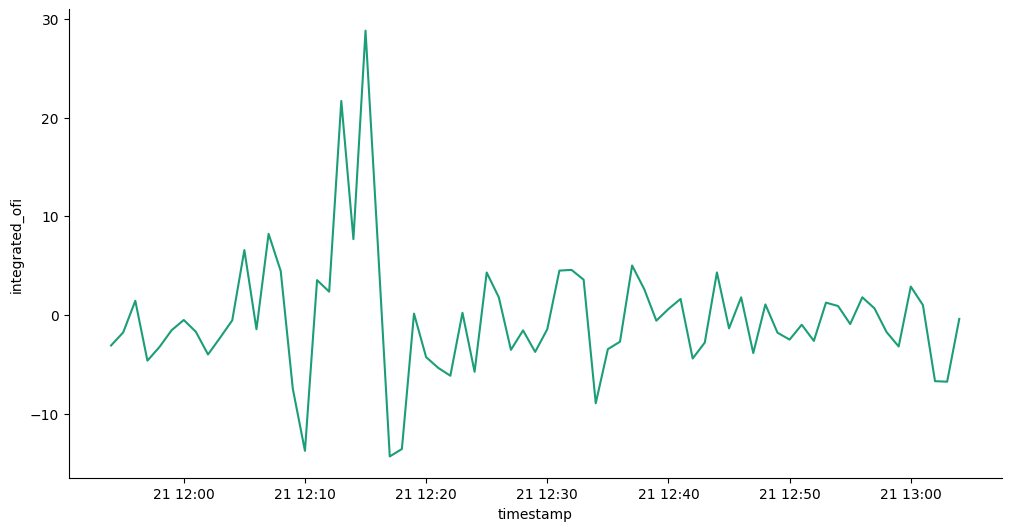

In [22]:
# @title timestamp vs integrated_ofi

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['timestamp']
  ys = series['integrated_ofi']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = integrated_ofi_df.sort_values('timestamp', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('timestamp')
_ = plt.ylabel('integrated_ofi')

In [23]:
cross_asset_ofi_df.head()

,timestamp,symbol,self_ofi_component,cross_ofi_component,total_cross_asset_ofi
0,2024-10-21 12:24:00+00:00,AAPL,-0.0,0,0.0
1,2024-10-21 12:25:00+00:00,AAPL,0.0,0,0.0
2,2024-10-21 12:26:00+00:00,AAPL,0.0,0,0.0
3,2024-10-21 12:27:00+00:00,AAPL,-0.0,0,0.0
4,2024-10-21 12:28:00+00:00,AAPL,-0.0,0,0.0
